In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

In [ ]:
!pip install tensorflow

In [ ]:
!pip install -U tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 54.0 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is inc

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH = '/content/biodeg_cleaned.xlsx'
TEST_SIZE = 0.20
N_SPLITS = 5

# upload data
df = pd.read_excel(DATA_PATH, engine='openpyxl')

# target and features
assert 'Class' in df.columns, "No Class Column"
y = df['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
X = df.drop(columns=['Class'])

In [4]:
# Feature engineering
count_cols = ['nHM', 'nO', 'nN', 'nArNO2', 'nCIR']
for c in count_cols:
    if c in X.columns:
        X[f'log_{c}'] = np.log1p(X[c])  # ln(x+1)

# Oranlar
if 'nN' in X.columns and 'nO' in X.columns:
    X['N_to_O_Ratio'] = X['nN'] / (X['nO'] + 1)

In [6]:
# Halojen yoğunluğu (kolon adları dosyaya göre değişebilir; örnek isimler)
br_col = None
cl_col = None
for col in X.columns:
    if 'C-Br' in col and 'B01' in col: br_col = col
    if 'C-Cl' in col and 'B03' in col: cl_col = col
if br_col and cl_col and ('nHM' in X.columns):
    X['Halo_Density'] = (X[br_col] + X[cl_col]) / (X['nHM'] + 1)

# Spektral indeks etkileşimi
if 'SpMax_L' in X.columns and {'nN','nO','nArNO2'}.issubset(X.columns):
    X['Index_Interaction'] = X['SpMax_L'] * (X['nN'] + X['nO'] + X['nArNO2'])

In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [8]:
# 7) NN structure
def build_model(input_dim, config):
    model = keras.Sequential(name=config.get('name', 'NN'))
    # Hidden layers
    for i, (units, dropout) in enumerate(zip(config['units'], config['dropout'])):
        if i == 0:
            model.add(layers.Dense(units, activation=config.get('activation','relu'),
                                   input_dim=input_dim))
        else:
            model.add(layers.Dense(units, activation=config.get('activation','relu')))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    # output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    # Optimizasyon
    opt = keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [9]:
# NN achitectures which will be tried
candidates = [
    {'name':'NN_32x2_dp0.2',       'units':[32, 32],     'dropout':[0.2, 0.2],     'lr':1e-3},
    {'name':'NN_64-32-16_dp0.3',   'units':[64, 32, 16], 'dropout':[0.3, 0.3, 0.3],'lr':1e-3},
    {'name':'NN_128-64_dp0.5',     'units':[128, 64],    'dropout':[0.5, 0.5],     'lr':5e-4},
    {'name':'NN_64x3_dp0.2',       'units':[64, 64, 64], 'dropout':[0.2, 0.2, 0.2],'lr':1e-3},
]

# 5-fold stratified CV function
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


In [10]:
def cross_val_score_nn(X_scaled, y, config):
    accs = []
    cw = class_weight.compute_class_weight(class_weight='balanced',
                                           classes=np.array([0,1]),
                                           y=y)
    cw_dict = {0: cw[0], 1: cw[1]}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_scaled, y), start=1):
        X_tr, X_val = X_scaled[tr_idx], X_scaled[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = build_model(X_scaled.shape[1], config)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)
        # trsin
        history = model.fit(
            X_tr, y_tr,
            epochs=200, batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[es],
            verbose=0,
            class_weight=cw_dict
        )
        # Evaluate
        y_val_pred = (model.predict(X_val, verbose=0).ravel() >= 0.5).astype(int)
        acc = accuracy_score(y_val, y_val_pred)
        accs.append(acc)

        # clear the resources
        tf.keras.backend.clear_session()
    return float(np.mean(accs)), float(np.std(accs))

In [11]:
# 10) Adayları CV ile değerlendir ve en iyileri seç
results = []
for cfg in candidates:
    mean_acc, std_acc = cross_val_score_nn(X_train_scaled, y_train, cfg)
    results.append({'Model':cfg['name'], 'CV_mean_acc':mean_acc, 'CV_std_acc':std_acc})

res_df = pd.DataFrame(results).sort_values('CV_mean_acc', ascending=False)
print("\n=== 5-Fold CV Sonuçları (Train/Val) ===")
print(res_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo


=== 5-Fold CV Sonuçları (Train/Val) ===
               Model  CV_mean_acc  CV_std_acc
0      NN_32x2_dp0.2     0.879198    0.030179
1  NN_64-32-16_dp0.3     0.875641    0.028604
3      NN_64x3_dp0.2     0.872091    0.025096
2    NN_128-64_dp0.5     0.864990    0.034026


In [12]:
# Evaluate the best 3 structures on test-set
best3 = res_df.head(3)['Model'].tolist()

def get_cfg_by_name(name):
    return next(c for c in candidates if c['name'] == name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> NN_32x2_dp0.2 – Test Accuracy: 0.8483
              precision    recall  f1-score   support

         NRB       0.80      0.73      0.76        71
          RB       0.87      0.91      0.89       140

    accuracy                           0.85       211
   macro avg       0.83      0.82      0.83       211
weighted avg       0.85      0.85      0.85       211



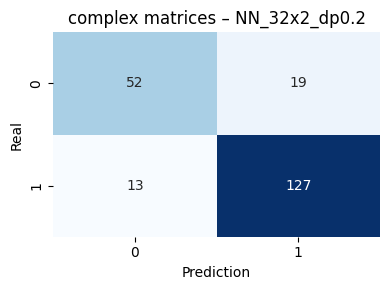

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> NN_64-32-16_dp0.3 – Test Accuracy: 0.8341
              precision    recall  f1-score   support

         NRB       0.76      0.75      0.75        71
          RB       0.87      0.88      0.88       140

    accuracy                           0.83       211
   macro avg       0.81      0.81      0.81       211
weighted avg       0.83      0.83      0.83       211



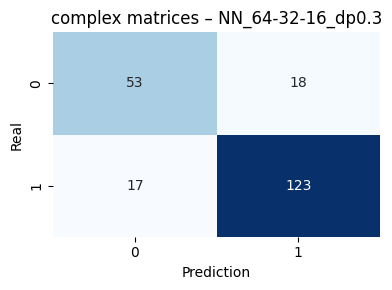

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> NN_64x3_dp0.2 – Test Accuracy: 0.8389
              precision    recall  f1-score   support

         NRB       0.78      0.72      0.75        71
          RB       0.86      0.90      0.88       140

    accuracy                           0.84       211
   macro avg       0.82      0.81      0.82       211
weighted avg       0.84      0.84      0.84       211



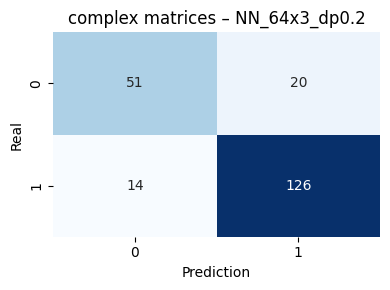

In [14]:
summary_rows = []
for mname in best3:
    cfg = get_cfg_by_name(mname)
    model = build_model(X_train_scaled.shape[1], cfg)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True)
    #Train with  Validation split
    history = model.fit(
        X_train_scaled, y_train,
        epochs=300, batch_size=32, validation_split=0.2,
        callbacks=[es], verbose=0
    )

    # Test performance
    y_test_proba = model.predict(X_test_scaled, verbose=0).ravel()
    y_test_pred  = (y_test_proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    print(f"\n>>> {mname} – Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_test_pred, target_names=['NRB','RB']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'complex matrices – {mname}')
    plt.xlabel('Prediction')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    summary_rows.append({
        'Model': mname,
        'Test_Accuracy': acc,
        'TP': cm[1,1], 'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0]
    })

In [15]:
# the table that is about the best 3 structure
summary_df = pd.DataFrame(summary_rows)
print("\n=== Task 1 – Sum of the best 3 structure ===")
print(summary_df)


=== Task 1 – Sum of the best 3 structure ===
               Model  Test_Accuracy   TP  TN  FP  FN
0      NN_32x2_dp0.2       0.848341  127  52  19  13
1  NN_64-32-16_dp0.3       0.834123  123  53  18  17
2      NN_64x3_dp0.2       0.838863  126  51  20  14


In [18]:
!pip install scikeras

In [19]:
!pip -q install catboost scikeras lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.6 MB/s eta 0:00:00


In [20]:
from scikeras.wrappers import KerasClassifier
from catboost import CatBoostClassifier, Pool

In [22]:

# --- Genel ayarlar ---
BASE_RANDOM_STATE = 42
N_SEEDS_DROP = 10           # Drop Column için 10 farklı RNG (split aynı, seed değişiyor)
N_SPLITS_PI = 10            # Permutation Importance için 10 farklı split
N_REPEATS_PI = 10           # Permutation Importance tekrar sayısı
TEST_SIZE_FALLBACK = 0.20   # Task 1'de yoksa fallback oranı (Assignment 2 oranını kullanın)


In [23]:

# --- Yardımcı: normalize & plot ---
def normalize_importances(d):
    vals = np.array(list(d.values()), dtype=float)
    s = vals.sum()
    if s <= 0:
        vals = np.abs(vals)
        s = vals.sum() if vals.sum() > 0 else 1.0
    vals = vals / s
    return {k: float(v) for k, v in zip(d.keys(), vals)}


In [24]:

def plot_importance_bar(imp_dict, title):
    items = sorted(imp_dict.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*items)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(labels), y=list(values), color='#4c78a8')
    plt.xticks(rotation=75)
    plt.ylabel('Normalize Önem (Toplam=1)')
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [25]:

# --- Task 1’den mimari seçimi yeniden kullan ---
def get_task1_best_cfg_or_fallback():
    """
    Task 1'de belirlediğin en iyi mimariyi (best3[0]) ve candidates listesini kullanır.
    Yoksa minimal bir fallback NN konfigürasyonu döner.
    """
    try:
        # Task 1 kodundan: candidates & get_cfg_by_name & best3
        assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
        if 'best3' in globals() and len(best3) > 0:
            return get_cfg_by_name(best3[0])
        else:
            # best3 yoksa ilk iyi aday
            return candidates[0]
    except Exception:
        # Fallback mimari
        return {
            'name':'NN_fallback_64-32-16',
            'units':[64, 32, 16],
            'dropout':[0.3, 0.3, 0.3],
            'lr':1e-3,
            'activation':'relu',
            'epochs':200,
            'batch_size':32,
            'patience':10
        }

In [26]:

# --- Task 1’deki build fonksiyonunu kullan veya fallback oluştur ---
def ensure_build_fn(input_dim, cfg):
    """
    Task 1'de build_model veya build_keras_sequential tanımlıysa onu kullanır,
    yoksa burada bir Sequential model oluşturur.
    """
    if 'build_model' in globals():
        return build_model(input_dim, cfg)
    elif 'build_keras_sequential' in globals():
        return build_keras_sequential(input_dim, cfg)
    else:
        # Fallback builder
        from tensorflow.keras import layers
        model = keras.Sequential(name=cfg.get('name','NN'))
        for i, (units, dp) in enumerate(zip(cfg['units'], cfg['dropout'])):
            if i == 0:
                model.add(layers.Dense(units, activation=cfg['activation'], input_dim=input_dim))
            else:
                model.add(layers.Dense(units, activation=cfg['activation']))
            if dp and dp > 0:
                model.add(layers.Dropout(dp))
        model.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg['lr'])
        model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return model


In [27]:

def fit_nn_with_val(X_tr_s, y_tr, X_val_s, y_val, cfg):
    es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                       patience=cfg.get('patience',10),
                                       restore_best_weights=True)
    model = ensure_build_fn(X_tr_s.shape[1], cfg)
    model.fit(X_tr_s, y_tr,
              epochs=cfg.get('epochs',200),
              batch_size=cfg.get('batch_size',32),
              validation_data=(X_val_s, y_val),
              callbacks=[es], verbose=0)
    return model


In [28]:

# --- Task 1’deki veri & split & scaler’ı yeniden kullan ---
def get_task1_data_or_fallback():
    """
    Task 1’den X, y, X_train, X_test, y_train, y_test, scaler değişkenlerini kullanır.
    Yoksa minimum fallback ile aynı isimli değişkenleri üretir.
    """
    # 1) X & y
    if 'X' in globals() and 'y' in globals():
        local_X, local_y = X.copy(), y.copy()
    else:
        # Fallback: dosyadan oku (Task 1'de zaten yüklü olmalıydı)
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        local_y = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        local_X = df_fb.drop(columns=['Class'])

    # 2) Train/Test split
    if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
        X_tr, X_te = X_train.copy(), X_test.copy()
        y_tr, y_te = y_train.copy(), y_test.copy()
        # Ölçekleyici
        if 'scaler' in globals():
            local_scaler = scaler
        else:
            local_scaler = StandardScaler().fit(X_tr)
    else:
        # Fallback split
        X_tr, X_te, y_tr, y_te = train_test_split(
            local_X, local_y, test_size=TEST_SIZE_FALLBACK,
            stratify=local_y, random_state=BASE_RANDOM_STATE
        )
        local_scaler = StandardScaler().fit(X_tr)

    # 3) Ölçeklenmiş matrisler (Task 1'dekileri tekrar hesaplamıyoruz; yoksa üretiyoruz)
    try:
        X_train_scaled_used = X_train_scaled  # Task 1’den
        X_test_scaled_used  = X_test_scaled
    except Exception:
        X_train_scaled_used = local_scaler.transform(X_tr)
        X_test_scaled_used  = local_scaler.transform(X_te)

    return local_X, local_y, X_tr, X_te, y_tr, y_te, local_scaler, X_train_scaled_used, X_test_scaled_used


In [29]:

# --- 1) NN – Drop Column Importance (10 RNG, split Task 1 ile aynı) ---
def drop_column_importance_nn_task1_split():
    """
    Aynı train/test split ve aynı baz scaler (Task 1’den) kullanılır.
    10 farklı seed ile NN yeniden eğitilir; her iterasyonda her özelliği düşürerek
    doğruluk farkı (base_acc - drop_acc) önem olarak kaydedilir.
    """
    X_all, y_all, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s = get_task1_data_or_fallback()
    cfg = get_task1_best_cfg_or_fallback()
    features = X_all.columns.tolist()

    # Baz doğruluk (Task 1 ölçeklemesi ile)
    tf.keras.backend.clear_session()
    model_base = fit_nn_with_val(X_tr_s, y_tr, X_te_s, y_te, cfg)
    y_pred_base = (model_base.predict(X_te_s, verbose=0).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y_te, y_pred_base)

    agg = defaultdict(list)

    for s in range(N_SEEDS_DROP):
        # RNG farklılaştırma (split aynı kalır)
        tf.random.set_seed(BASE_RANDOM_STATE + s)
        np.random.seed(BASE_RANDOM_STATE + s)

        for f in features:
            # Kolonu düşür
            X_tr_drop = X_tr.drop(columns=[f])
            X_te_drop = X_te.drop(columns=[f])
            # Düşürülmüş veri için yeni scaler (şart: boyut değişti)
            scaler_drop = StandardScaler().fit(X_tr_drop)
            X_tr_drop_s = scaler_drop.transform(X_tr_drop)
            X_te_drop_s = scaler_drop.transform(X_te_drop)

            # Eğit ve değerlendir
            tf.keras.backend.clear_session()
            model_drop = fit_nn_with_val(X_tr_drop_s, y_tr, X_te_drop_s, y_te, cfg)
            y_pred_drop = (model_drop.predict(X_te_drop_s, verbose=0).ravel() >= 0.5).astype(int)
            acc_drop = accuracy_score(y_te, y_pred_drop)

            imp = max(0.0, base_acc - acc_drop)
            agg[f].append(imp)

    mean_imp = {f: float(np.mean(vals)) for f, vals in agg.items()}
    mean_imp_norm = normalize_importances(mean_imp)
    return mean_imp, mean_imp_norm

# --- 2) NN – Permutation Importance (10 farklı split, n_repeats=10) ---


In [30]:

# --- 2) NN – Permutation Importance (10 farklı split, n_repeats=10) ---
def permutation_importance_nn_multi_splits():
    """
    Task gereği 10 farklı split ile permutation importance.
    Task 1 mimarisi (best cfg) yeniden kullanılır.
    """
    # Task 1’den X, y
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_imp = np.zeros(len(features), dtype=float)
    cfg = get_task1_best_cfg_or_fallback()

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # SciKeras ile sklearn-style sınıflandırıcı
        def builder():
            # Input boyutuna göre Task 1 mimarisi
            model = ensure_build_fn(X_tr_s.shape[1], cfg)
            return model

        sk_model = KerasClassifier(model=builder,
                                   epochs=cfg.get('epochs',200),
                                   batch_size=cfg.get('batch_size',32),
                                   verbose=0)
        sk_model.fit(X_tr_s, y_tr)

        pi = permutation_importance(
            sk_model, X_te_s, y_te,
            n_repeats=N_REPEATS_PI,
            random_state=BASE_RANDOM_STATE + s,
            scoring='accuracy'
        )
        sum_imp += np.maximum(0.0, pi.importances_mean)

        tf.keras.backend.clear_session()

    mean_imp = sum_imp / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm

In [31]:

# --- 3) Logistic Regression – 10 farklı split ---
def logistic_regression_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_abs = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        lr = LogisticRegression(
            max_iter=2000, solver='liblinear',
            class_weight='balanced',
            random_state=BASE_RANDOM_STATE + s
        )
        lr.fit(X_tr_s, y_tr)
        coefs = lr.coef_.ravel()
        sum_abs += np.abs(coefs)

    mean_abs = sum_abs / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_abs)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


In [32]:

# --- 4) CatBoost – 10 farklı split (Varyantın: 3 → Classification Q4 = CatBoost) ---
def catboost_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_imp = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        train_pool = Pool(X_tr, y_tr)
        valid_pool = Pool(X_te, y_te)

        cat = CatBoostClassifier(
            iterations=400, learning_rate=0.05, depth=6,
            loss_function='Logloss', eval_metric='Accuracy',
            random_state=BASE_RANDOM_STATE + s,
            verbose=False
        )
        cat.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50, verbose=False)
        imp = np.array(cat.get_feature_importance(train_pool), dtype=float)
        sum_imp += np.maximum(0.0, imp)

    mean_imp = sum_imp / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


In [33]:

# 1) NN – Drop Column (Task 1 split ve scaler ile)
dc_raw, dc_norm = drop_column_importance_nn_task1_split()
print("\n[NN – Drop Column] (normalize edilmemiş) En yüksek 10:")
print(pd.Series(dc_raw).sort_values(ascending=False).head(10))
plot_importance_bar(dc_norm, "NN – Drop Column Importance (Normaliz


SyntaxError: unterminated string literal (detected at line 5) (ipython-input-2802576306.py, line 5)